How the Mean Reversion Strategy Works
💡 Concept:

The price tends to revert to its mean (average) over time.
If the price drops too much below the mean → BUY (expecting it to bounce back).
If the price rises too much above the mean → SELL (expecting it to drop back).
Uses Bollinger Bands to define "too much".

📌 Indicators Used:

✅ Simple Moving Average (SMA) – 20-period average price.

✅ Bollinger Bands – Upper & lower bands (2 standard deviations away).

### Fetch Historical Data Using Binance REST API ###

First, we’ll fetch historical OHLCV data from Binance using the REST API.

In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:


BASE_URL = "https://api.binance.com/api/v3"

def get_historical_data(symbol, interval="1h", limit=100):
    """Fetch historical OHLCV data from Binance API"""
    url = f"{BASE_URL}/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        raise Exception(f"Error fetching data: {response.text}")

    data = response.json()
    
    # Convert response to Pandas DataFrame
    columns = ["timestamp", "open", "high", "low", "close", "volume",
               "close_time", "quote_asset_volume", "trades",
               "taker_buy_base", "taker_buy_quote", "ignore"]
    
    df = pd.DataFrame(data, columns=columns)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df["close"] = df["close"].astype(float)

    return df[["timestamp", "close"]]


🔹 Fetches the last 100 candles (1-hour interval by default).

🔹 Returns a DataFrame with timestamps and closing prices.

### Calculate Bollinger Bands ###

Now, we calculate Bollinger Bands, which will tell us if the price is too high or too low.

In [2]:
def calculate_bollinger_bands(df, period=20, std_dev=2):
    """Calculate Bollinger Bands (SMA ± 2 standard deviations)"""
    df["SMA"] = df["close"].rolling(window=period).mean()
    df["STD"] = df["close"].rolling(window=period).std()
    
    df["Upper Band"] = df["SMA"] + (std_dev * df["STD"])
    df["Lower Band"] = df["SMA"] - (std_dev * df["STD"])

    return df


🔹 SMA (Simple Moving Average) = 20-period average.

🔹 Upper Band = SMA + 2 standard deviations.

🔹 Lower Band = SMA - 2 standard deviations.

### Define Trading Rules ###

We generate buy/sell signals based on Bollinger Bands.

In [4]:
def generate_signals(df):
    """Generate buy/sell signals based on Bollinger Bands"""
    df["Buy Signal"] = df["close"] < df["Lower Band"]  # Buy when price < lower band
    df["Sell Signal"] = df["close"] > df["Upper Band"]  # Sell when price > upper band
    return df


In [8]:
def plot_strategy(df, symbol):
    """Plot the strategy with Bollinger Bands and Buy/Sell signals"""
    plt.figure(figsize=(14, 7))
    
    # Plot closing price and Bollinger Bands
    plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", alpha=0.6)
    plt.plot(df["timestamp"], df["SMA"], label="SMA (20)", color="black", linestyle="dashed")
    plt.plot(df["timestamp"], df["Upper Band"], label="Upper Band", color="red", linestyle="dashed")
    plt.plot(df["timestamp"], df["Lower Band"], label="Lower Band", color="green", linestyle="dashed")
    
    # Plot Buy signals
    plt.scatter(df["timestamp"][df["Buy Signal"]], df["close"][df["Buy Signal"]], 
                label="Buy Signal", marker="^", color="green", s=100)
    
    # Plot Sell signals
    plt.scatter(df["timestamp"][df["Sell Signal"]], df["close"][df["Sell Signal"]], 
                label="Sell Signal", marker="v", color="red", s=100)
    
    plt.title(f"{symbol} - Mean Reversion Strategy with Bollinger Bands")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

             timestamp     close         SMA    Upper Band    Lower Band  \
90 2025-02-26 22:00:00  84433.51  87193.0395  90974.030149  83412.048851   
91 2025-02-26 23:00:00  84250.09  86960.5440  90869.282747  83051.805253   
92 2025-02-27 00:00:00  84742.39  86762.9660  90702.145792  82823.786208   
93 2025-02-27 01:00:00  84763.25  86579.9485  90534.363847  82625.533153   
94 2025-02-27 02:00:00  84295.20  86348.6995  90267.655423  82429.743577   
95 2025-02-27 03:00:00  85226.32  86174.0145  89957.018085  82391.010915   
96 2025-02-27 04:00:00  85161.93  86007.8840  89652.970142  82362.797858   
97 2025-02-27 05:00:00  85883.13  85846.2415  89184.830503  82507.652497   
98 2025-02-27 06:00:00  86265.84  85696.4005  88634.335312  82758.465688   
99 2025-02-27 07:00:00  86280.23  85579.5720  88196.866112  82962.277888   

    Buy Signal  Sell Signal  
90       False        False  
91       False        False  
92       False        False  
93       False        False  
94       Fals

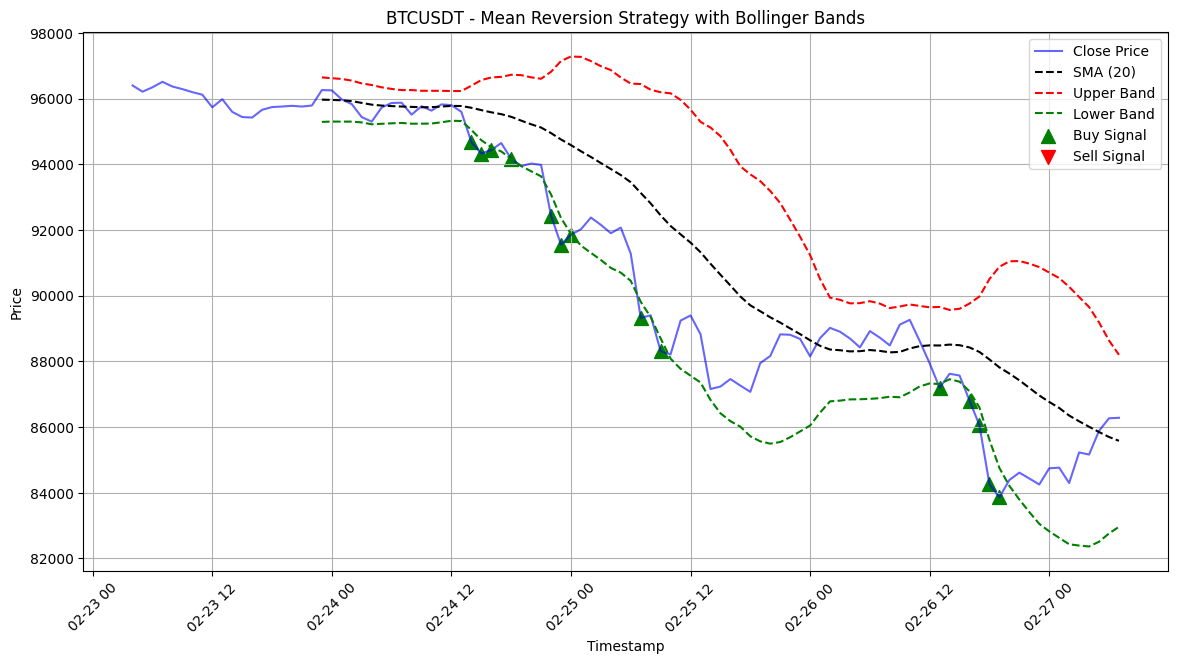

In [9]:
def run_strategy(symbol="BTCUSDT", interval="1h", limit=100):
    """Run Mean Reversion Strategy"""
    df = get_historical_data(symbol, interval, limit)
    df = calculate_bollinger_bands(df)
    df = generate_signals(df)

    # Display buy/sell signals
    print(df[["timestamp", "close", "SMA", "Upper Band", "Lower Band", "Buy Signal", "Sell Signal"]].tail(10))
    plot_strategy(df, symbol)

# Example usage
run_strategy("BTCUSDT")


# Backtesting the Mean Reversion Strategy #

Now, let's backtest our Mean Reversion strategy using historical Binance data. This means:

✅ Simulating past trades based on our signals

✅ Tracking profit/loss for each trade

✅ Calculating overall performance (Win Rate, ROI, etc.)


In [11]:
import numpy as np

def backtest_strategy(df, initial_balance=1000, trade_size=0.1):
    """Backtest the Mean Reversion strategy and calculate performance metrics"""
    
    balance = initial_balance  # Starting balance in USD
    position = 0  # BTC holdings
    trades = []  # Track trade history
    
    for i in range(len(df)):
        price = df["close"].iloc[i]
        
        # Buy Signal (if not already holding BTC)
        if df["Buy Signal"].iloc[i] and position == 0:
            position = (balance * trade_size) / price  # Buy BTC
            balance -= position * price
            trades.append({"timestamp": df["timestamp"].iloc[i], "action": "BUY", "price": price})
        
        # Sell Signal (if holding BTC)
        elif df["Sell Signal"].iloc[i] and position > 0:
            balance += position * price  # Sell BTC
            position = 0
            trades.append({"timestamp": df["timestamp"].iloc[i], "action": "SELL", "price": price})
    
    # Final portfolio value (if holding BTC, sell at last price)
    final_value = balance + (position * df["close"].iloc[-1])
    
    # Performance metrics
    total_trades = len(trades) // 2  # One buy + one sell = 1 complete trade
    roi = ((final_value - initial_balance) / initial_balance) * 100  # % return
    
    print(f"📊 Final Balance: ${final_value:.2f} (ROI: {roi:.2f}%)")
    print(f"📈 Total Trades Executed: {total_trades}")
    
    # Convert trades to DataFrame for analysis
    trades_df = pd.DataFrame(trades)
    print(trades_df)
    
    return trades_df, final_value, roi


📊 Final Balance: $991.22 (ROI: -0.88%)
📈 Total Trades Executed: 0
            timestamp action     price
0 2025-02-24 14:00:00    BUY  94674.44


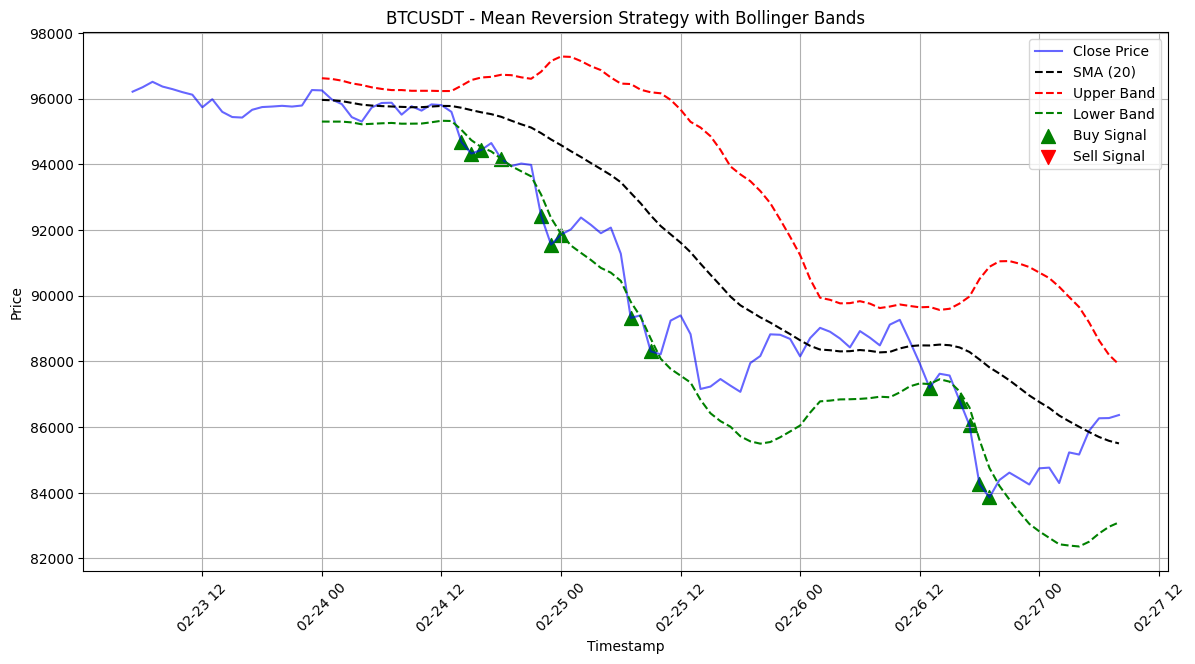

In [12]:
def run_backtest(symbol="BTCUSDT", interval="1h", limit=100):
    """Run backtest for the Mean Reversion strategy"""
    df = get_historical_data(symbol, interval, limit)
    df = calculate_bollinger_bands(df)
    df = generate_signals(df)
    
    # Run backtest
    trades, final_balance, roi = backtest_strategy(df)
    
    # Plot strategy with trades
    plot_strategy(df, symbol)

# Run backtest for BTCUSDT
run_backtest("BTCUSDT")
